# Notebook 2 — Static vs. Dynamic Features: Time, State, and Memory

> **Learning Objectives**
> - Understand the conceptual distinction between *Static* (instantaneous) and *Dynamic* (trajectory-based) features
> - Learn how `StaticFeature.__call__` always picks **only the latest frame** from the window
> - Learn how `DynamicFeature.__call__` uses the **entire tensor** chronologically
> - Understand that the choice of `max_length` has no bearing on Static features
> - Empirically compare a Static and a Dynamic feature on contrasting gesture trials

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pyeyesweb.data_models import SlidingWindow
from pyeyesweb.low_level import BoundingBoxFilledArea, KineticEnergy, Smoothness
from examples.utils.data_loader import GestureDataLoader
from examples.utils.plot_utils import plot_feature_timeseries

loader = GestureDataLoader("data")

## 1. The Root Question: How Much Time Does a Feature Need?

Every feature in PyEyesWeb is implemented as either a **`StaticFeature`** or a **`DynamicFeature`**. This classification is determined by one simple question:

> **Does this measurement require knowing what happened in previous frames?**

| | Static Feature | Dynamic Feature |
|--|---------------|-----------------|
| **Memory needed** | 1 frame only | N frames (a trajectory) |
| **Input to `compute()`** | `(N_signals, N_dims)` — a single snapshot | `(Time, N_signals, N_dims)` — a 3-D tensor |
| **Example** | "What is the body volume right now?" | "Was the motion smooth over the last 0.5 seconds?" |
| **Correct `max_length`** | `1` | Depends on feature (typically 30–300 frames) |

Both types are accessed through **the same streaming interface** (`window → feature(window)`), but the internal dispatch is completely different — as we will see below.

---

## 2. `StaticFeature` — The Instantaneous Snapshot

### 2.1 How it works internally

When you call `feature(window)` on a `StaticFeature`, the base class automatically:

1. Calls `window.to_tensor()` to get the 3-D buffer `(T, N, D)`
2. **Takes only the very last frame**: `frame_data = tensor[-1]` — shape `(N_signals, N_dims)`
3. Passes it to `self.compute(frame_data)`

This means the window size is irrelevant for Static features — they will always operate on the newest frame regardless of how many frames the buffer holds.

### 2.2 Demonstration: `BoundingBoxFilledArea` (Contraction Index)

The Contraction Index measures the ratio of the body's 3-D convex hull surface area to its bounding box surface area. It is purely geometric and needs only a single pose.

In [2]:
pos_tensor, _, _, marker_names = loader.load("trial10", sensor="qualisys")
N_frames = pos_tensor.shape[0]
N_joints = pos_tensor.shape[1]

# For a static feature, max_length=1 is semantically correct...
window_static = SlidingWindow(max_length=1, n_signals=N_joints, n_dims=3)

# ...but max_length=60 gives the same result!
window_static_big = SlidingWindow(max_length=60, n_signals=N_joints, n_dims=3)

contraction = BoundingBoxFilledArea()

results_small = []
results_big   = []

for t in range(N_frames):
    frame = pos_tensor[t, :, :]
    window_static.append(frame)
    window_static_big.append(frame)

    r_small = contraction(window_static)
    r_big   = contraction(window_static_big)

    results_small.append(r_small.contraction_index)
    results_big.append(r_big.contraction_index)

results_small = np.array(results_small)
results_big   = np.array(results_big)

# The two time-series must be identical
print(f"Max difference: {np.max(np.abs(results_small - results_big)):.2e}")
# → Max difference: 0.00e+00  (they are exactly the same)

Max difference: 0.00e+00


> **Key insight**: A `StaticFeature` only ever uses `tensor[-1]`. The window size can be `max_length=1` (which is the logical minimum), or any larger value — the result is always the same.

---

## 3. `DynamicFeature` — The Trajectory Reader

### 3.1 How it works internally

When you call `feature(window)` on a `DynamicFeature`, the base class:

1. Calls `window.to_tensor()` to get the full 3-D buffer `(T, N, D)`
2. Passes the **entire tensor** to `self.compute(tensor)`

The feature then processes the full time axis — looking at velocity changes, frequency content, directional reversals, etc.

### 3.2 Demonstration: `Smoothness` (SPARC)

SPARC (Spectral Arc Length) measures whether the velocity profile over a window is smooth and bell-shaped, or fragmented and multi-peaked. It fundamentally needs a trajectory.

In [3]:
hand_idx = marker_names.index("LWristOut")

# Smoothness expects a 1-D speed profile: n_signals=1, n_dims=1
window_dynamic = SlidingWindow(max_length=60, n_signals=1, n_dims=1)
smooth_feature = Smoothness(rate_hz=100.0, metrics=["jerk_rms"])

vel_tensor = np.gradient(pos_tensor, axis=0) * 100.0  # finite difference velocity
hand_speed = np.linalg.norm(vel_tensor[:, hand_idx, :], axis=1)  # scalar speed

sparc_log = []
for t in range(N_frames):
    window_dynamic.append(hand_speed[t])

    if window_dynamic.is_full:
        result = smooth_feature(window_dynamic)
        sparc_log.append(result.jerk_rms)

sparc_log = np.array(sparc_log)
print(f"Jerk range: [{sparc_log.min():.2f}, {sparc_log.max():.2f}]")
print("Higher = less smooth (more sub-movements in the velocity)")

Jerk range: [2237.58, 44357.14]
Higher = less smooth (more sub-movements in the velocity)


## 4. Side-by-Side Comparison on a Full Trial

Let us run both features on the same trial and visualise how they evolve over time.

Processing:   0%|          | 0/3612 [00:00<?, ?it/s]

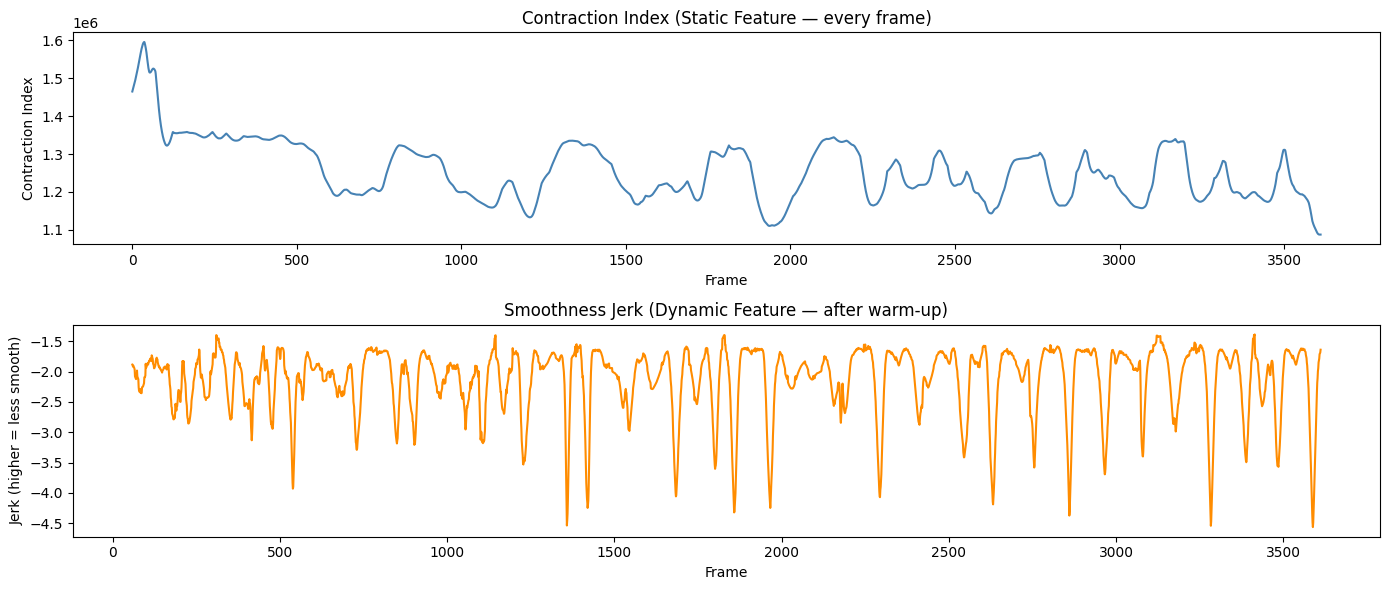

In [5]:
# Reset and re-fill
window_s = SlidingWindow(max_length=1,  n_signals=N_joints, n_dims=3)  # Static
window_d = SlidingWindow(max_length=60, n_signals=1,       n_dims=1)  # Dynamic

contraction_ft = BoundingBoxFilledArea()
smooth_ft      = Smoothness(rate_hz=100.0, metrics=["sparc"])

log_contraction = []
log_sparc       = []
time_sparc      = []

for t in tqdm(range(N_frames), desc="Processing"):
    window_s.append(pos_tensor[t, :, :])
    window_d.append(hand_speed[t])

    # Static: available every frame (no warm-up needed)
    log_contraction.append(contraction_ft(window_s).contraction_index)

    # Dynamic: wait for the buffer to fill
    if window_d.is_full:
        log_sparc.append(smooth_ft(window_d).sparc)
        time_sparc.append(t)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(log_contraction, color="steelblue")
axes[0].set_title("Contraction Index (Static Feature — every frame)")
axes[0].set_ylabel("Contraction Index")
axes[0].set_xlabel("Frame")

axes[1].plot(time_sparc, log_sparc, color="darkorange")
axes[1].set_title("Smoothness Jerk (Dynamic Feature — after warm-up)")
axes[1].set_ylabel("Jerk (higher = less smooth)")
axes[1].set_xlabel("Frame")

plt.tight_layout()
plt.show()

> **Observation**: The Contraction Index produces a value at every frame from the very start. Jerk only begins after 60 frames (0.6 s) — the window's warm-up period.

## 5. The Warm-Up Period and `is_full`

When a `DynamicFeature` is initialised, its window is empty. Running the feature on an empty or partially-filled window would produce meaningless results (e.g., SPARC computed on 2 samples has no spectral meaning).

The guard condition is `window.is_full`:

In [6]:
window = SlidingWindow(max_length=60, n_signals=1, n_dims=1)

for t in range(100):
    window.append(np.random.rand())

    if not window.is_full:
        # Skip computation during warm-up
        continue

    result = smooth_ft(window)
    # … log result

> An alternative: PyEyesWeb features return `FeatureResult(is_valid=False)` when the window is empty (length 0). However, a partially-filled window is **not** guarded by the library — it is the caller's responsibility to check `is_full` for dynamic features.

## 6. Choosing the Right `max_length` for Dynamic Features

The window length defines the **temporal scope** of the analysis. This is a genuinely scientific choice:

| Window (at 100 Hz) | Duration | Best for |
|--------------------|----------|---------|
| 10 frames | 0.1 s | Very fast sub-movements, finger taps |
| 60 frames | 0.6 s | Standard gesture analysis (limb movements) |
| 120 frames | 1.2 s | Full reach, walking gait cycles |
| 300 frames | 3.0 s | Sustained postures, slow dance phrases |

In [7]:
# Experiment: how does window size affect smoothness measurement?
for window_len in [20, 60, 120, 300]:
    w = SlidingWindow(max_length=window_len, n_signals=1, n_dims=1)
    sf = Smoothness(rate_hz=100.0, metrics=["jerk_rms"])
    log = []
    for t in range(N_frames):
        w.append(hand_speed[t])
        if w.is_full:
            log.append(sf(w).jerk_rms)
    if log:
        print(f"Window={window_len:3d} frames | Mean Jerk: {np.mean(log):.3f} | Std: {np.std(log):.3f}")

Window= 20 frames | Mean Jerk: 10538.409 | Std: 8458.767
Window= 60 frames | Mean Jerk: 11227.047 | Std: 6621.480
Window=120 frames | Mean Jerk: 11523.586 | Std: 5179.525
Window=300 frames | Mean Jerk: 11718.914 | Std: 3893.552


## 7. 🧪 Experiment: Compare Static vs. Dynamic on Two Contrasting Trials

Load one **impulsive** trial and one **fluid** trial (use whichever file names match your dataset). Then apply both a Static and a Dynamic feature and compare:

In [8]:
# Adjust filenames to your actual data
trial_A, _, _, _ = loader.load("trial10", sensor="qualisys")
trial_B, _, _, _ = loader.load("trial11", sensor="qualisys")

for label, data in [("Trial A", trial_A), ("Trial B", trial_B)]:
    # Static
    w_s = SlidingWindow(max_length=1, n_signals=data.shape[1], n_dims=3)
    ci = BoundingBoxFilledArea()
    ci_vals = []
    for t in range(data.shape[0]):
        w_s.append(data[t])
        ci_vals.append(ci(w_s).contraction_index)

    # Dynamic
    vel = np.gradient(data, axis=0) * 100.0
    h_idx = 0  # Use first joint if marker_names unavailable
    spd = np.linalg.norm(vel[:, h_idx, :], axis=1)
    w_d = SlidingWindow(max_length=60, n_signals=1, n_dims=1)
    sf = Smoothness(rate_hz=100.0, metrics=["jerk_rms"])
    jerk_vals = [sf(w_d).jerk_rms for t in range(data.shape[0])
                  if (w_d.append(spd[t]) or True) and w_d.is_full]

    print(f"\n{label}")
    print(f"  Mean Contraction Index : {np.mean(ci_vals):.3f}")
    print(f"  Mean Jearj             : {np.mean(jerk_vals):.3f}")


Trial A
  Mean Contraction Index : 1255161.516
  Mean Jearj             : 8762.739

Trial B
  Mean Contraction Index : 1234848.273
  Mean Jearj             : 2458.612


**Questions to reflect on:**
1. Does the impulsive trial have higher or lower mean SPARC (less smooth) than the fluid trial?
2. Does the contraction index differ between trials? What does this tell you about posture?
3. What happens to SPARC if you halve `max_length` to 30 frames?

---

## Summary

| | Static Feature | Dynamic Feature |
|--|---------------|-----------------|
| **Base class** | `StaticFeature` | `DynamicFeature` |
| **`compute()` input shape** | `(N_signals, N_dims)` | `(Time, N_signals, N_dims)` |
| **What `__call__` passes** | Only `tensor[-1]` (the newest frame) | The full tensor |
| **`max_length` effect** | None — always uses 1 frame | Determines temporal scope |
| **Warm-up required?** | No | Yes — use `is_full` guard |
| **Typical examples** | Contraction, KineticEnergy, PointsDensity | Smoothness, DirectionChange, Suddenness |

In **Notebook 3**, we will explore the second major axis of variation: the **Streaming API** (`__call__`) vs. the **Pure Math API** (`.compute()`), and learn when each is appropriate.